In [1]:
import matplotlib.pyplot as plt

import torch

device = torch.device('cpu')#torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float32

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True


In [2]:
from orbitflows import HamiltonianMappingModel

model = HamiltonianMappingModel.load("best_sho")
model.flow.to(device)

Flow(
  (layers): ModuleList(
    (0-63): 64 x SymplecticCouplingLayer(
      (conditioner): SimpleNNConditioner(
        (layers): Sequential(
          (0): Linear(in_features=1, out_features=64, bias=True)
          (1): ReLU()
          (2): Linear(in_features=64, out_features=1, bias=True)
        )
      )
    )
  )
)

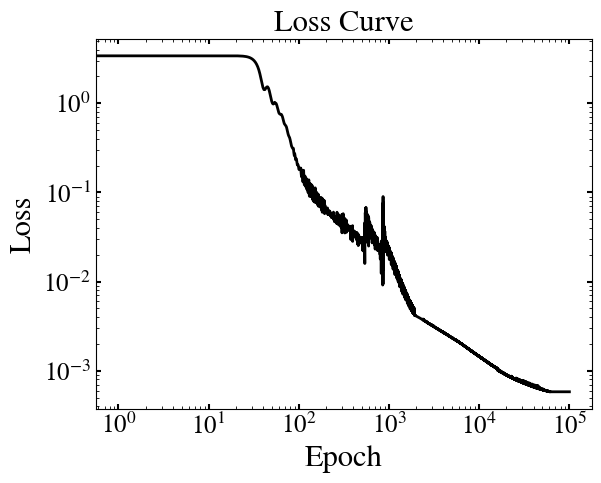

In [3]:
plt.loglog(model.loss_list, c='k', lw=2)
plt.xlabel('Epoch', fontsize=22)
plt.ylabel('Loss', fontsize=22)
plt.title('Loss Curve', fontsize=22)
plt.show()

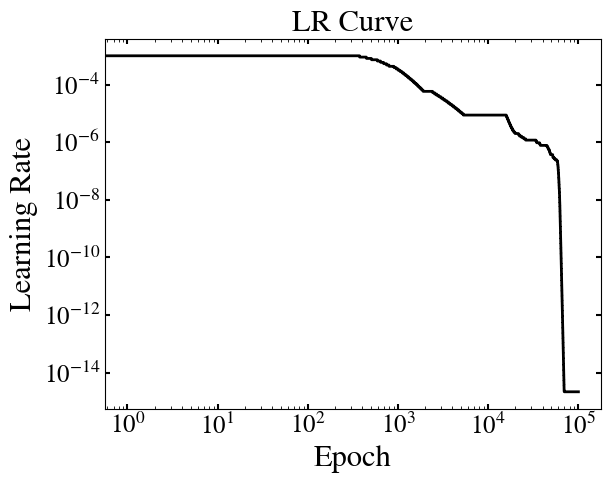

In [24]:
plt.loglog(model.lr_list, c='k', lw=2)
plt.xlabel('Epoch', fontsize=22)
plt.ylabel('Learning Rate', fontsize=22)
plt.title('LR Curve', fontsize=22)
plt.show()

In [19]:
import astropy.units as u
from orbitflows.util import generate_sho_orbits
ro = 8.0 * u.kpc
vo = 220.0 * u.km / u.s
n_orbits = 100
n_angles = 1000
omega0 = 1.1
z_max_0 = 0.5/ro.value
z_max_1 = 7/ro.value

ex_ps, ex_aa = generate_sho_orbits(n_orbits=n_orbits, omega=omega0, t_end = 2*torch.pi / omega0, n_steps=n_angles, r_bounds=torch.tensor([z_max_0, z_max_1]))
ex_model_ps = model.aa_to_ps(ex_aa.to(device=device, dtype=torch.float32))
z_max_list = torch.max(ex_model_ps[...,0], dim=1).values * ro.value#ex_model_ps[:,0][:,0]*ro.value

In [20]:
training_bounds_ps, training_bounds_aa = generate_sho_orbits(n_orbits=2, omega=omega0, t_end = 2*torch.pi / omega0, n_steps=n_angles, r_bounds=[0.15, 0.75])
true_bounds_ps = model.aa_to_ps(training_bounds_aa.to(device=device, dtype=torch.float32))
z_max_bounds = torch.max(true_bounds_ps[...,0], dim=1).values * ro.value #true_bounds_ps[:,0][:,0]*ro.value

In [21]:
model.targetPotential

functools.partial(<function sho_potential at 0x7e9cc9ee25c0>, omega=tensor(1.5000))

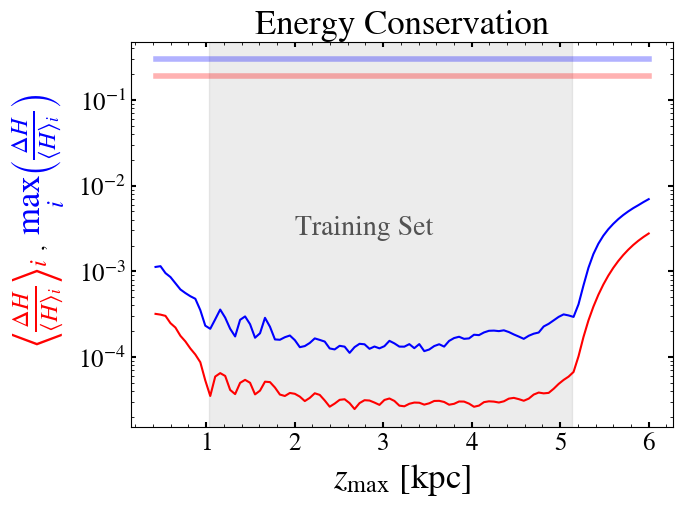

In [22]:
from orbitflows.util import max_error_along_orbs, mean_error_along_orbs
from orbitflows.dynamics import H
import numpy as np

fig, ax = plt.subplots(figsize=(7, 5))
y_max = torch.max(max_error_along_orbs(H(ex_ps, model.targetPotential)).detach().cpu())
y_min = torch.min(mean_error_along_orbs(H(ex_model_ps, model.targetPotential)).detach().cpu())
y_mean = 10**torch.mean(torch.tensor([torch.log10(y_min), torch.log10(y_max)]))

plt.axvspan(z_max_bounds.detach().cpu()[0], z_max_bounds.detach().cpu()[1], alpha=0.15, color='gray')
plt.text(torch.mean(z_max_bounds).detach().cpu()*0.65, y_mean, "Training Set", fontsize=20, alpha=0.65)

ax.plot(z_max_list.detach().cpu(), max_error_along_orbs(H(ex_ps, model.targetPotential)).detach().cpu(), c='b', alpha=0.3, lw=4)
ax.plot(z_max_list.detach().cpu(), mean_error_along_orbs(H(ex_ps, model.targetPotential)).detach().cpu(),  c='r', alpha=0.3, lw=4)

ax.plot(z_max_list.detach().cpu(), max_error_along_orbs(H(ex_model_ps, model.targetPotential)).detach().cpu(), label='Max along orbit', c='b')
ax.plot(z_max_list.detach().cpu(), mean_error_along_orbs(H(ex_model_ps, model.targetPotential)).detach().cpu(), label='Mean along orbit', c='r')

ax.set_xlabel('$z_{\\text{max}}$ [kpc]', fontsize=25)
# plt.ylabel('$ \Delta H / \langle H \\rangle$', fontsize=25)
# Add colored vertical label pieces
ax.text(
    -0.17, 0.50, r"$\max_i \left ( \frac{\Delta H}{\langle H \rangle_{i}} \right )$",
    transform=ax.transAxes,
    color="blue",
    fontsize=25,
    rotation=90,
    ha="center",
    va="bottom"
)

ax.text(
    -0.17, 0.47, ",",
    transform=ax.transAxes,
    color="black",
    fontsize=16,
    rotation=90,
    ha="center",
    va="center"
)

ax.text(
    -0.17, 0.44, r"$\left \langle \frac{\Delta H}{\langle H \rangle_{i}} \right \rangle_{i}$",
    transform=ax.transAxes,
    color="red",
    fontsize=25,
    rotation=90,
    ha="center",
    va="top"
)

ax.set_title('Energy Conservation', fontsize=25)
ax.set_yscale('log')
plt.savefig('best_sho_performance.png', dpi=200, bbox_inches='tight')
plt.show()

* **Red** = mean energy error along each orbit
* **Blue** = max energy error along each orbit

The thick lines are from before training.

In [ ]:
arg_min_bound = torch.argmin(torch.abs(z_max_list - z_max_bounds[0])) 
arg_max_bound = torch.argmin(torch.abs(z_max_list - z_max_bounds[1])) 

print(f'Worst (log10) Error of All Points in the Training Set Domain: ')
print(f'{torch.log10(max_error_along_orbs(H(ex_model_ps, model.targetPotential))[arg_min_bound : arg_max_bound].max()).item():.2f}')

Worst (log10) Error of All Points in the Training Set Domain: 
-2.74
